In [3]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_log_file(log_file_path):
    """
    Parse the .log file to extract training and testing losses.

    Args:
        log_file_path (str): Path to the .log file.

    Returns:
        dict: A dictionary containing train and test losses over epochs.
    """
    train_losses = []
    test_losses = []
    Ldl_losses = []
    with open(log_file_path, 'r') as file:
        for line in file:
            # Match train loss lines
            #train_match = re.match(r"\[Epoch \d+\] (.+)", line)
            train_match = re.match(r"\[Epoch \d+\],\s*(.+)", line)
            if train_match:
                train_losses.append([float(x.strip()) for x in train_match.group(1).split(",")])

            # Match test loss lines
            test_match = re.match(r"\(test\)\s+(.+)", line)
            if test_match:
                test_losses.append([float(x.strip()) for x in test_match.group(1).split(",")])

            # Match test loss lines
            Ldl_match = re.match(r"\s*Ldl\s+(.+)", line)
            if Ldl_match:
                Ldl_losses.append([float(x.strip()) for x in Ldl_match.group(1).split(",")])

    return {
        "train": np.array(train_losses),
        "test": np.array(test_losses),
        "Ldl": np.array(Ldl_losses)
    }

def plot_loss_evolution(loss_data, k_levels=None, save_path=None):
    """
    Plot the loss evolution over epochs for selected `k` levels during training and testing.

    Args:
        loss_data (dict): A dictionary containing train and test losses over epochs.
        k_levels (list, optional): List of `k` levels to plot. Defaults to all available levels.
        save_path (str, optional): Path to save the plot. If None, the plot is displayed.
    """
    train_losses = loss_data['train']
    test_losses = loss_data['test']
    Ldl_losses = loss_data['Ldl']

    if k_levels is None:
        k_levels = range(train_losses.shape[1])  # Default to all levels

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 6))
    for k in k_levels:
        if k < train_losses.shape[1]:  # Ensure k is valid
            plt.plot(epochs, train_losses[:, k], label=f"Train Loss Level {k}")
            if len(test_losses) > 0:
                plt.plot(epochs, test_losses[:, k], '--', label=f"Test Loss Level {k}")
            if len(Ldl_losses) > 0:
                plt.plot(epochs, Ldl_losses[:, k], '--', label=f"Test Loss Level {k}")
        else:
            print(f"Warning: k level {k} is out of bounds and will be ignored.")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Evolution Over Epochs")
    plt.legend()
    plt.grid()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    else:
        plt.show()



In [11]:
# Example usage
log_file_path = "saved_models_17062025/log.txt"  # Replace with the path to your .log file
loss_data = parse_log_file(log_file_path)



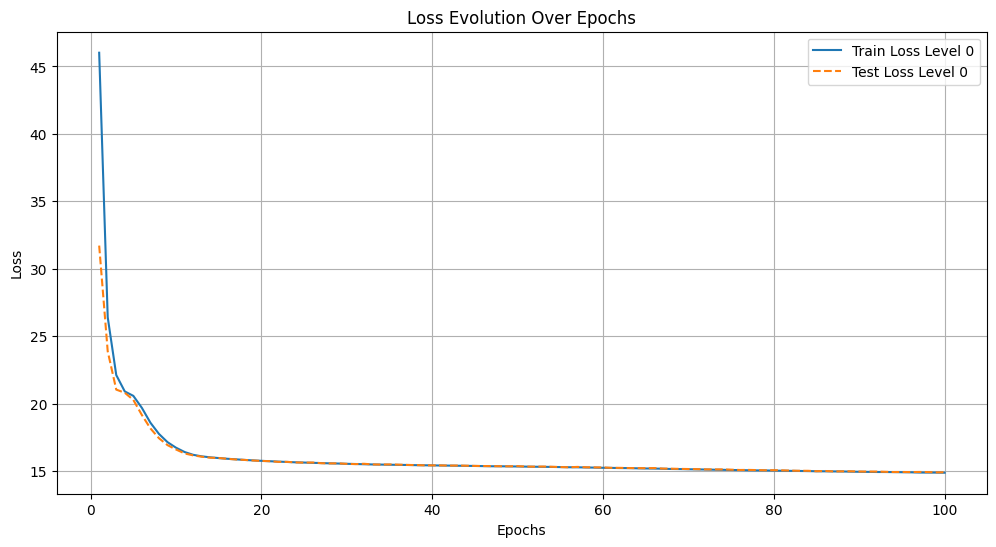

In [14]:
# Specify the `k` levels you want to plot, or set to `None` to plot all levels
k_levels_to_plot = [0]  # Example: Plot only levels 0 and 2
plot_loss_evolution(loss_data, k_levels=k_levels_to_plot, save_path="loss_evolution_k_levels.png")  # Replace with None to display the plot

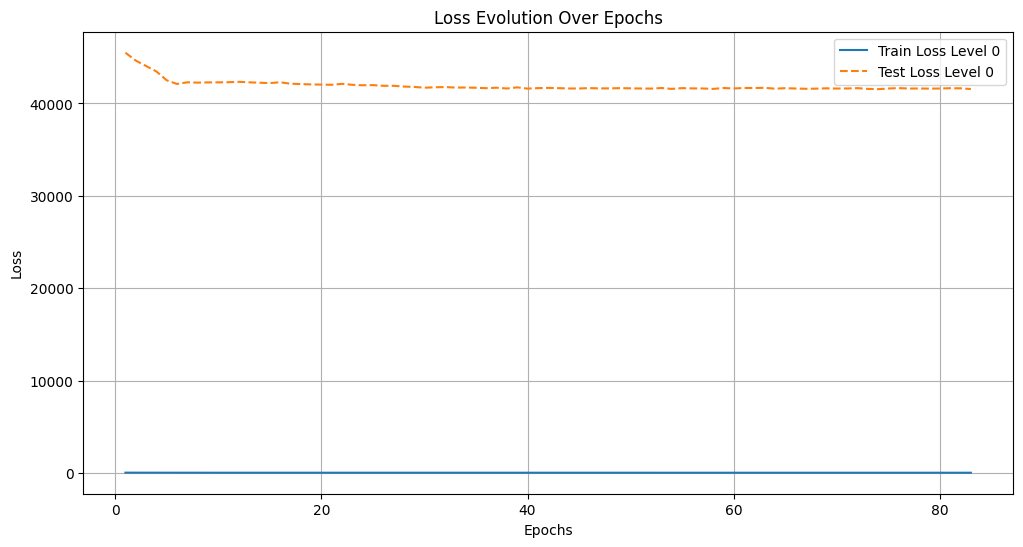

In [5]:
# plot Ldl (Loss latent decodings) too

log_file_path = "saved_models_17062025_2/log.txt"  # Replace with the path to your .log file
loss_data = parse_log_file(log_file_path)
k_levels_to_plot = [0]
plot_loss_evolution(loss_data, k_levels=k_levels_to_plot, save_path="loss_evolution_k_levels.png")  # Replace with None to display the plot

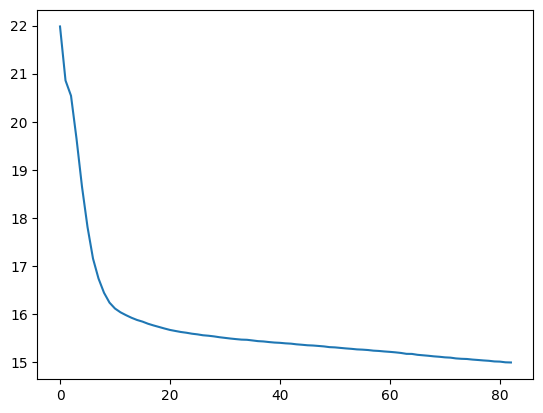

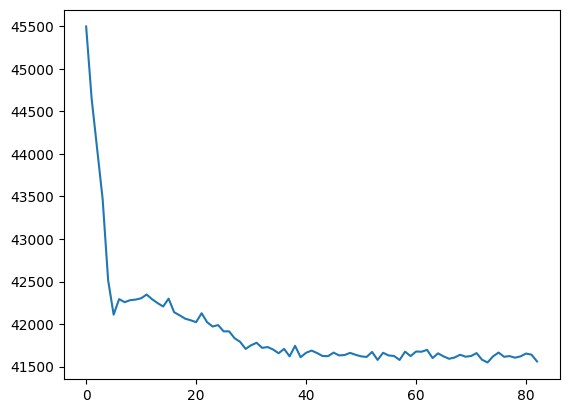

In [9]:
plt.plot(loss_data["train"])
#plt.plot(loss_data["test"])
plt.show()
plt.plot(loss_data["Ldl"])
plt.show()